In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


# Initial EDA

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_train=pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv")

In [4]:
df_train.head()

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,...,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,...,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,...,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,...,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,...,0,0.0,0,0,0.0,1.0,7.0,2018-09-15 19:34:00,2018-09-11,0


To know the columns and their types

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

To find the descriptive statistics of the numerical features

In [6]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
IsBetaUser,100000.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00
RealTimeProtectionState,99934.0,6.848430e+00,1.015166e+00,0.0,7.0,7.0,7.000000e+00,8.000000e+00
IsPassiveModeEnabled,100000.0,1.762000e-02,1.315664e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
AntivirusConfigID,99924.0,4.797571e+04,1.380332e+04,39.0,49480.0,53447.0,5.344700e+04,7.049000e+04
NumAntivirusProductsInstalled,99924.0,1.326528e+00,5.206814e-01,1.0,1.0,1.0,2.000000e+00,5.000000e+00
NumAntivirusProductsEnabled,99924.0,1.018264e+00,1.552909e-01,0.0,1.0,1.0,1.000000e+00,4.000000e+00
HasTpm,100000.0,9.967800e-01,5.665389e-02,0.0,1.0,1.0,1.000000e+00,1.000000e+00
CountryID,100000.0,1.080788e+02,6.306215e+01,1.0,51.0,97.0,1.620000e+02,2.220000e+02
CityID,99377.0,8.102994e+04,4.894403e+04,7.0,36694.0,82373.0,1.228350e+05,1.679570e+05
GeoRegionID,100000.0,1.697416e+02,8.918893e+01,1.0,89.0,181.0,2.670000e+02,2.960000e+02


In [7]:
from sklearn.dummy import DummyClassifier

In [8]:
X_train=df_train.iloc[:,:-1]
y_train=df_train.iloc[:,-1]

In [9]:
Dummy=DummyClassifier()
Dummy.fit(X_train,y_train)

DummyClassifier()

In [10]:
X_test=pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv")

**A submit function that takes the classifier and submits the predicted values.**

In [11]:
def submit(clf,X_test):
    y_pred=clf.predict(X_test)
    sub=pd.DataFrame({"id":range(0,X_test.shape[0]),"target":y_pred})
    sub.to_csv("submission.csv",index=False)

In [12]:
X_train['IsBetaUser'].value_counts(),X_test['IsBetaUser'].value_counts()

(IsBetaUser
 0    100000
 Name: count, dtype: int64,
 IsBetaUser
 0    10000
 Name: count, dtype: int64)

**IsBetaUser  
AutoSampleSubmissionEnabled  
IsFlightsDisabled     
all have 0s 
while IsFlightsDisabled has a few null values**

Columns with a null value

In [13]:
for i in df_train:
    if df_train[i].isnull().sum()>0:
        print(i)#columns with null value will be printed

RealTimeProtectionState
AntivirusConfigID
NumAntivirusProductsInstalled
NumAntivirusProductsEnabled
CityID
IsSystemProtected
SMode
IEVersionID
FirewallEnabled
EnableLUA
OEMNameID
OEMModelID
ProcessorCoreCount
ProcessorManufacturerID
ProcessorModelID
PrimaryDiskCapacityMB
PrimaryDiskType
SystemVolumeCapacityMB
TotalPhysicalRAMMB
ChassisType
PrimaryDisplayDiagonalInches
PrimaryDisplayResolutionHorizontal
PrimaryDisplayResolutionVertical
InternalBatteryNumberOfCharges
OSInstallLanguageID
IsFlightsDisabled
FirmwareManufacturerID
FirmwareVersionID
IsVirtualDevice
IsAlwaysOnAlwaysConnectedCapable
IsGamer
RegionIdentifier
DateOS


In [14]:
from seaborn import heatmap
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

In [15]:
d1=DummyClassifier(strategy='most_frequent')
d1.fit(X_train,y_train)

DummyClassifier(strategy='most_frequent')

# Milestone 1


In [16]:
df_mile1=pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')

In [17]:
df_mile1=df_mile1.dropna()

In [18]:
df_mile1.shape

(96695, 76)

 1. How many unique versions of the operating system are present in the dataset?abs


In [19]:
df_mile1['OSVersion'].unique().shape[0]

7

2. What is the maximum value of the feature “NumAntivirusProductsInstalled”?

In [20]:
df_mile1['NumAntivirusProductsInstalled'].value_counts()

NumAntivirusProductsInstalled
1.0    67424
2.0    26991
3.0     2185
4.0       90
5.0        5
Name: count, dtype: int64

3. In how many systems owned by gamers was malware detected? 

In [21]:
(df_mile1[df_mile1['IsGamer']==1]['target']==1).sum()

15991

4. For observations where the feature “IsPassiveModeEnabled” equals “1,” what is the most frequent value of the feature “RealTimeProtectionState”? 

In [22]:
df_mile1[df_mile1['IsPassiveModeEnabled']==1]['RealTimeProtectionState'].value_counts()

RealTimeProtectionState
0.0    1708
3.0       8
1.0       1
Name: count, dtype: int64

5. How many systems have a screen resolution of 1366 x 768?
   

In [23]:
(df_mile1[df_mile1['PrimaryDisplayResolutionHorizontal']==1366]['PrimaryDisplayResolutionVertical']==768).sum()

49926

6. What is the 50th percentile value of “TotalPhysicalRAMMB”? 

In [24]:
df_mile1['TotalPhysicalRAMMB'].median()

4096.0

# Plottings

In [25]:
import matplotlib.pyplot as plt

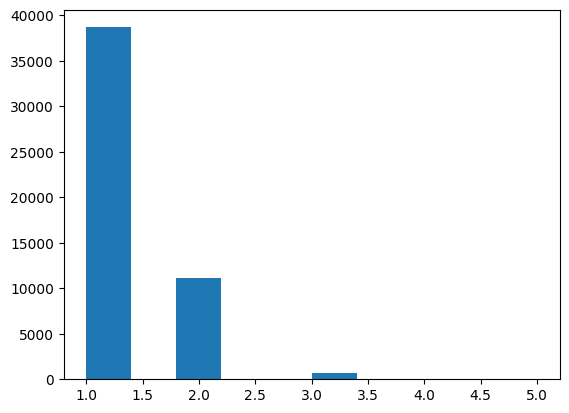

In [26]:
plt.hist(df_train[df_train['target']==1]['NumAntivirusProductsInstalled']);

In [27]:
df_train[df_train['target']==1]['NumAntivirusProductsInstalled'].value_counts()

NumAntivirusProductsInstalled
1.0    38683
2.0    11111
3.0      678
4.0       27
5.0        1
Name: count, dtype: int64

In [28]:
df_train[df_train['target']==0]['NumAntivirusProductsInstalled'].value_counts()

NumAntivirusProductsInstalled
1.0    31065
2.0    16714
3.0     1577
4.0       64
5.0        4
Name: count, dtype: int64

We see that among those who have installed 1 Antivirus product there is almost equal chance of being under threat.

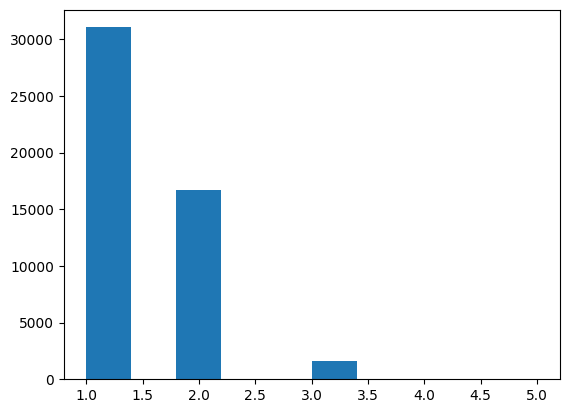

In [29]:
plt.hist(df_train[df_train['target']==0]['NumAntivirusProductsInstalled']);

(array([8.8000e+01, 0.0000e+00, 4.9745e+04, 0.0000e+00, 0.0000e+00,
        6.4700e+02, 0.0000e+00, 1.9000e+01, 0.0000e+00, 1.0000e+00]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

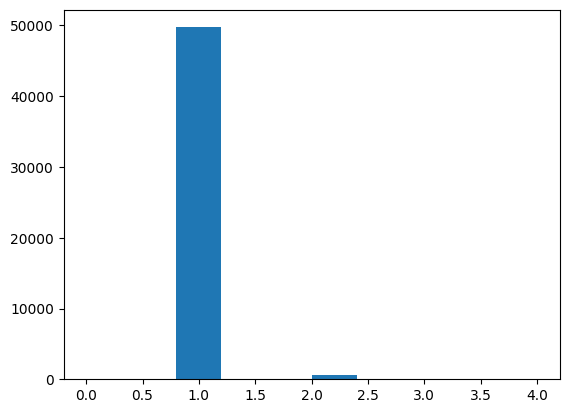

In [30]:
plt.hist(df_train[df_train['target']==1]['NumAntivirusProductsEnabled'])

(array([1.590e+02, 0.000e+00, 4.792e+04, 0.000e+00, 0.000e+00, 1.307e+03,
        0.000e+00, 3.700e+01, 0.000e+00, 1.000e+00]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

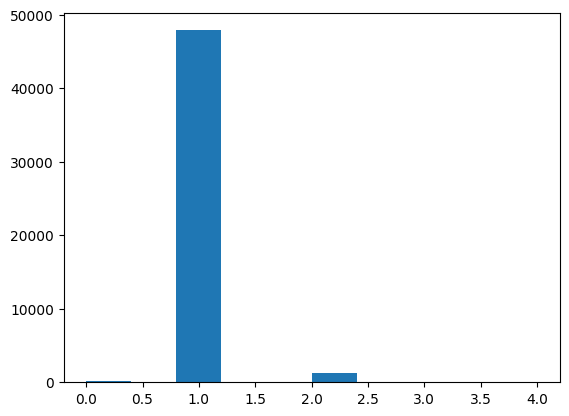

In [31]:
plt.hist(df_train[df_train['target']==0]['NumAntivirusProductsEnabled'])

In [32]:
df_train[df_train['target']==1]['NumAntivirusProductsEnabled'].value_counts()

NumAntivirusProductsEnabled
1.0    49745
2.0      647
0.0       88
3.0       19
4.0        1
Name: count, dtype: int64

In [33]:
df_train[df_train['target']==0]['NumAntivirusProductsEnabled'].value_counts()

NumAntivirusProductsEnabled
1.0    47920
2.0     1307
0.0      159
3.0       37
4.0        1
Name: count, dtype: int64

A very similar image is seen in this case too. One cannot comment on the computers with 4 enabled because there are only 4 such instances.

(array([  814.,  3262.,     0.,  7447., 39002.]),
 array([ 7601. ,  9633.4, 11665.8, 13698.2, 15730.6, 17763. ]),
 <BarContainer object of 5 artists>)

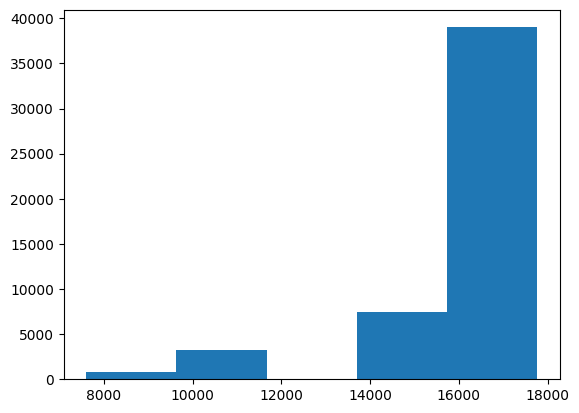

In [34]:
plt.hist(df_train[df_train['target']==1]['OSBuildNumber'],bins=5)

(array([  813.,  3715.,     0.,  8307., 36640.]),
 array([ 7601. ,  9633.4, 11665.8, 13698.2, 15730.6, 17763. ]),
 <BarContainer object of 5 artists>)

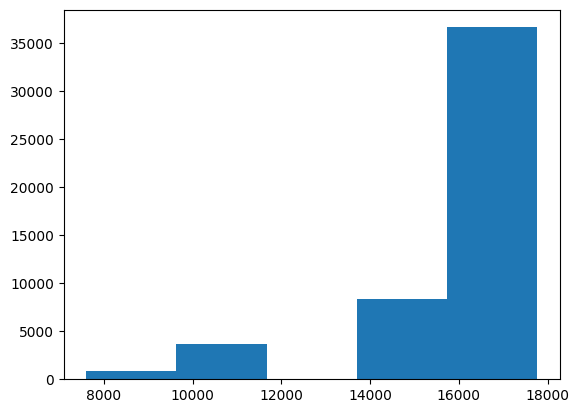

In [35]:
plt.hist(df_train[df_train['target']==0]['OSBuildNumber'],bins=5)

In [36]:
df_train[df_train['target']==1]['OSBuildNumber'].value_counts()

OSBuildNumber
17134    24260
16299    14661
15063     4074
14393     3373
10586     1720
10240     1542
9600       712
7601       102
17692       13
17738       11
17744        9
17758        8
17735        7
17746        6
17763        5
17741        5
17755        5
17751        4
17713        3
17672        2
17754        1
17730        1
17760        1
Name: count, dtype: int64

In [37]:
df_train[df_train['target']==0]['OSBuildNumber'].value_counts()

OSBuildNumber
17134    21577
16299    14971
15063     4302
14393     4005
10586     2149
10240     1566
9600       689
7601       124
17744       17
17692       13
17741        9
17738        9
17713        8
17746        8
17735        7
17758        6
17760        4
17672        2
17751        2
17754        2
17755        2
17763        1
17686        1
17730        1
Name: count, dtype: int64

In [38]:
df_train['OSBuildNumber'].min(),df_train['OSBuildNumber'].max()

(7601, 17763)

In [39]:
(df_train['OSBuildNumber']==17134).sum()

45837

Definition of OSBuildNumber (acc. to GPT) - An OS build number is a specific identifier assigned to a particular compilation of an operating system. It indicates the exact state of the OS at a certain point in its development or update cycle.

The OSBuildNumber has it's values spread between 7601 and 17763. 

However since 45837 instances has a build number of 17134(about 45.837%) the histogram tends to peak over it. 

# Data preprocessing with first Approach

In [40]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier,LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [42]:
from sklearn.compose import ColumnTransformer

In [43]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

In [44]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [45]:
df=pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
X,y=df.iloc[:,:-1],df.iloc[:,-1]

Procedure here is add columns check if the accuracy score of train and test increase,then add it or else remove it. 


In [46]:
ct2=ColumnTransformer(
    [
        ('ord',OrdinalEncoder(),[1,2,3,4]),
        ('is beta user','drop',[5]),
        ('real_time_protect',make_pipeline(SimpleImputer(strategy='constant',fill_value=0.0)),[6]),
        ('ispassive','passthrough',[7]),
        #('antivirusconfigid',make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(sparse_output=False)),[8]),
        ('num_anti',SimpleImputer(strategy='constant',fill_value=0.0),[9]),
        ('hasTPM','passthrough',[11]),
        #('countryID',OneHotEncoder(sparse_output=False),[12]),
        ('platform_type and processor',OneHotEncoder(),[16,17]),
        ('Osproductsuite, osplatform and buildlab,sku edition',OneHotEncoder(sparse_output=False),[21]),
        ("is sys protected",SimpleImputer(strategy='constant',fill_value=0),[24]),
        ("smode",SimpleImputer(strategy='constant',fill_value=0),[26]),
        ('IEVersionID',SimpleImputer(strategy='constant',fill_value=40),[27]),
        ('Firewall enabled,LUA',SimpleImputer(strategy='constant',fill_value=0),[28,29]),
        ("OEMName_id",make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(sparse_output=False)),[31,32]),
        ("Processor count",make_pipeline(SimpleImputer(strategy='most_frequent'),OrdinalEncoder()),[34]),
        ("proc man id",make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(sparse_output=False)),[35,36]),
        ("os architec",OneHotEncoder(),[49,50,52]),
        ("firmware man id",make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder()),[64]),
        ("Is sec boot",'passthrough',[66])
    ]
)

In [47]:
X_trans=pd.DataFrame(ct2.fit_transform(X))

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X_trans,y,test_size=0.2,random_state=39)

In [49]:
lr=LogisticRegression(max_iter=10000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=10000)

In [50]:
accuracy_score(y_train,lr.predict(X_train))

0.5886375

In [51]:
accuracy_score(y_test,lr.predict(X_test))

0.59185

Since the training and test accuracy seem to be similar (0.5% difference) We can say that the logistic regressor here does not overfit

# Milestone 2

In [52]:
df_mile2=pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
X_mile2,y_mile2=df_mile2.iloc[:,:-1],df_mile2.iloc[:,-1]

1. Identify the redundant columns in the training dataset based on the values taken.

In [53]:
for i in X_mile2:
    if X_mile2[i].nunique()==1:
        print(i)

IsBetaUser
AutoSampleSubmissionEnabled
IsFlightsDisabled


2. Determine the columns among the given set which have the highest positive correlation.

a. DateAS and SignatureVersion

b. OSBuildLab and NumericOSVersion

c.OSEdition and OSSkuFriendlyName

d.OSProductSuite and OSSkuFriendlyName

In [54]:
from scipy.stats import chi2_contingency

In [55]:
ctab=pd.crosstab(index=X_mile2['OSEdition'],columns=X_mile2['OSSkuFriendlyName'])
ChiSqResult = chi2_contingency(ctab)
print(ChiSqResult[1])

0.0


3. Create a new dataframe called cat_df which contains only the columns of datatype  'object'. In cat_df, for all the columns which take less than or equal to 10 unique values, use OneHotEncoder(sparse=False, drop='first', handle_unknown='ignore'). What is the new number of columns in the cat_df dataframe?

In [56]:
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer

In [57]:
cat_df=X_mile2[X_mile2.select_dtypes(include=['object']).columns]
l_10=[]
for i in cat_df:
    if cat_df[i].nunique()<=10:
        l_10.append(i)
ct=ColumnTransformer(
    [
        ('less than 10 values',OneHotEncoder(sparse=False,drop='first',handle_unknown='ignore'),l_10),
    ],
    remainder='passthrough'
)
X_mile2_cat_df_trans=pd.DataFrame(ct.fit_transform(cat_df))
X_mile2_cat_df_trans.shape

(100000, 82)

4. Create a new dataframe called num_df which contains only the columns of datatype  'int64' and 'float64'. Use MinMaxScaler() on num_df. What is the sum of all the values in num_df?

In [58]:
num_df=X_mile2[X_mile2.select_dtypes(include=['int64','float64']).columns]
X_mile2_num_df_trans=pd.DataFrame(MinMaxScaler().fit_transform(num_df))
X_mile2_num_df_trans.sum().sum()

1534590.729433082

Use the original data (X,y) for this question. Apply the following steps on X:
1. Use SimpleImputer to fill missing values with strategy as 'most_frequent'
2. For all columns of datatype 'object', use OrdinalEncoder()
3. Apply train_test_split with test_size = 0.2 and random_state = 42
4. Train SGDClassifier with default parameters and random_state = 42

What is the accuracy score received on the test data from the train_test_split?

In [59]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [60]:
X_mile2_step1=pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X_mile2))
ct5=ColumnTransformer(
    [
     ('Ordinal_encoding',OrdinalEncoder(),X_mile2_step1.select_dtypes(include=['object']).columns)
    ],
    remainder='passthrough'
)
X_mile2_trans=ct5.fit_transform(X_mile2_step1)

In [61]:
X_mile2_train,X_mile2_test,y_mile2_train,y_mile2_test=train_test_split(X_mile2_trans,y,test_size=0.2,random_state=42)

In [62]:
sgd_mile2=SGDClassifier(random_state=42)
sgd_mile2.fit(X_mile2_train,y_mile2_train)
accuracy_score(y_mile2_test,sgd_mile2.predict(X_mile2_test))

0.4951

For imputation, certain columns like 'RealTimeProtectionState', 'NumAntivirusProductsInstalled','IsSystemProtected','SMode ', 'IEVersionID' had a constant value like 0 or minimum value imputed, as logically, they are boolean, and it is safe to impute them with 0 rather than impute them with 1.
In my second approach, I used 'most_frequent' as the strategy for a generalised approach.

For Scaling, I tried MinMaxScaler and StandardScaler, since StandardScaler has yielded more accuracy, I went with it. 

For encoding, I used Ordinal encoding for 'ProductName', 'EngineVersion','AppVersion' ,'SignatureVersion' as they are ordered and must have that order preserved. And 'PlatformType', 'Processor', ' OsPlatformSubRelease' with OneHotEncoder as these values are of equal importance. However, for my second approach, I have used OneHotEncoder for all object based columns 

# Second Approach

I will be using a generic approach rather than column Specific transformation

In [63]:
cat_colns=X.select_dtypes(include=['object']).columns
num_colns=X.select_dtypes(include=['number']).columns

In [64]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [66]:
from sklearn.model_selection import GridSearchCV

In [67]:
ct2=ColumnTransformer(
    [
        ('cat_colns',make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(handle_unknown='infrequent_if_exist')),cat_colns),
        ('num_colns',make_pipeline(SimpleImputer(strategy='mean'),StandardScaler()),num_colns)
    ]
)
pipe2=make_pipeline(ct2,LogisticRegression())

In [68]:
pg={
    'logisticregression__solver':['liblinear'],
    'logisticregression__max_iter':[1000,10000],
    'logisticregression__C':[0.001,0.01]
}

In [69]:
gs=GridSearchCV(pipe2,pg,cv=3,n_jobs=-1,scoring='accuracy')

In [70]:
gs.fit(X_train,y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('cat_colns',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType...
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                                       ('logisticregression',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.001, 0.01],
                         'logisticregression__max_iter': [1000, 10000],
                         'logisticregression__solver': ['liblinear']},
             scoring='accuracy')

In [71]:
accuracy_score(y_train,gs.predict(X_train))

0.6251125

In [72]:
accuracy_score(y_test,gs.predict(X_test))

0.61455

It seems to be overfitting heavily, despite using gridsearch, thus, need to be regularised.

before regularisation:
train=0.868
test=0.61


after regularisation
train=0.625
test=0.61455

In [73]:
from sklearn.linear_model import Perceptron, SGDClassifier,RidgeClassifier

In [74]:
pipe_sgd=make_pipeline(ct2,SGDClassifier())
pipe_pc=make_pipeline(ct2,Perceptron())
pipe_rc=make_pipeline(ct2,RidgeClassifier())

In [75]:
pipe_sgd.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'O...
       'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID',
       'OSUILocaleID', 'IsPortableOS', 'IsFlightsDisabled',
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                ('sgdclassifier', SGDClassifier())])

In [76]:
pipe_pc.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'O...
       'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges',
       'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID',
       'OSUILocaleID', 'IsPortableOS', 'IsFlightsDisabled',
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                ('perceptron', Perceptron())])

In [77]:
pipe_rc.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'O...
       'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID',
       'OSUILocaleID', 'IsPortableOS', 'IsFlightsDisabled',
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                ('ridgeclassifier', RidgeClassifier())])

In [78]:
print("Accuracy score of Perceptron=","train=",accuracy_score(y_train,pipe_pc.predict(X_train)),"test=",accuracy_score(y_test,pipe_pc.predict(X_test)))
print("Accuracy score of RidgeClassifier=","train=",accuracy_score(y_train,pipe_rc.predict(X_train)),"test=",accuracy_score(y_test,pipe_rc.predict(X_test)))
print("Accuracy score of  SGD= ","train=",accuracy_score(y_train,pipe_sgd.predict(X_train)),"test=",accuracy_score(y_test,pipe_sgd.predict(X_test)))

Accuracy score of Perceptron= train= 0.9466875 test= 0.5663
Accuracy score of RidgeClassifier= train= 0.999825 test= 0.6089
Accuracy score of  SGD=  train= 0.6782875 test= 0.6054


This is very much expected as all the models are not hyper_tuned so they heavily overfit. However, due to the loss function in SGD it tend to memorise very less as compared to perceptron or RidgeClassifier 

Accuracy score of Perceptron= train= 0.9466875 test= 0.5663

Accuracy score of RidgeClassifier= train= 0.999825 test= 0.6089

Accuracy score of  SGD=  train= 0.6706125 test= 0.6106

# Dimensionality reduction and feature selection

In [79]:
from sklearn.feature_selection import SelectKBest

In [80]:
pipe_skb=make_pipeline(ct2,SelectKBest(),LogisticRegression(solver='liblinear',max_iter=1000))

In [81]:
pg={
    'selectkbest__k':[10,15,25,30]
}
gs_skb=GridSearchCV(pipe_skb,pg,scoring='accuracy')

In [82]:
gs_skb.fit(X_train,y_train)

GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('cat_colns',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Pr...
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                                       ('selectkbest', SelectKBest()),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=1000,
                                                           solver='liblinear'))]),
             param_grid={'selectkbest__k': [10, 15, 25, 30]},
             scoring='accuracy')

In [83]:
accuracy_score(y_train,gs_skb.predict(X_train))

0.6039875

In [84]:
accuracy_score(y_test,gs_skb.predict(X_test))

0.60255

This does not overfit however does not go above the 0.60 mark. 

In [85]:
from sklearn.decomposition import PCA,TruncatedSVD #PCA does not work with sparse_output but this notebook would die if it is not a sparse o/p 

In [86]:
from sklearn.naive_bayes import BernoulliNB,CategoricalNB,GaussianNB

In [87]:
pipe_svd=make_pipeline(ct2,TruncatedSVD(n_components=15),BernoulliNB())
pipe_svd.fit(X_train,y_train)
print(accuracy_score(y_train,pipe_svd.predict(X_train)))
print(accuracy_score(y_test,pipe_svd.predict(X_test)))

0.5639
0.5653


Bernoulli NB - training accuracy = 0.563125

test = 0.5637

They do not overfit, however the scores are very low

Trying without any decomposition

In [88]:
pipe_nb=make_pipeline(ct2,BernoulliNB(alpha=100)) # At first it had a 0.70 accuracy due to overfiitting, so changed the regularisation term
pipe_nb.fit(X_train,y_train)
print(accuracy_score(y_train,pipe_nb.predict(X_train)))
print(accuracy_score(y_test,pipe_nb.predict(X_test)))

0.52085
0.51875


The scores are worse 

In [89]:
from sklearn.neighbors import KNeighborsClassifier

In [90]:
#pipe_knn=make_pipeline(ct2,TruncatedSVD(n_components=25),KNeighborsClassifier(n_jobs=-1))
#pipe_knn.fit(X_train,y_train)
#print(accuracy_score(y_train,pipe_knn.predict(X_train)))
#print(accuracy_score(y_test,pipe_knn.predict(X_test)))

KNN model is overfitting with n=5 and takes so much time, hence it has been commented out

In [91]:
from sklearn.svm import SVC,LinearSVC
from sklearn.kernel_approximation import Nystroem

In [92]:
pipe_svc=make_pipeline(ct2,Nystroem(kernel='linear',n_jobs=-1),LinearSVC())

Nystroem has been used as that is useful for large datasets

In [93]:
pipe_svc.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'O...
       'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID',
       'OSUILocaleID', 'IsPortableOS', 'IsFlightsDisabled',
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                ('nystroem', Nystroem(kernel='linear', n_jobs=-1)),
                ('linearsvc', LinearSVC())])

In [94]:
accuracy_score(y_train,pipe_svc.predict(X_train))

0.6096125

In [95]:
accuracy_score(y_test,pipe_svc.predict(X_test))

0.6086

We have crossed the 0.61 mark here. 

In [96]:
from sklearn.neural_network import BernoulliRBM,MLPClassifier

In [97]:
pipe_nn=make_pipeline(ct2,MLPClassifier(hidden_layer_sizes=(10,15),alpha=1))
pipe_nn.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'O...
       'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID',
       'OSUILocaleID', 'IsPortableOS', 'IsFlightsDisabled',
       'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled',
       'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable',
       'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier'],
      dtype='object'))])),
                ('mlpclassifier',
                 MLPClassifier(alpha=1, hidden_layer_sizes=(10, 15)))])

In [98]:
print(accuracy_score(y_train,pipe_nn.predict(X_train)))
print(accuracy_score(y_test,pipe_nn.predict(X_test)))

0.6206875
0.61235


Heavy overfitting, Needs to be regularised

Before 
train= 0.999925

test=0.5923

After

train= 0.620225

test= 0.6147

In [99]:
#pg={
#    "mlpclassifier__alpha":[0.001,1]
#}

In [100]:
#gs_nn=GridSearchCV(pipe_nn,pg,cv=3,n_jobs=-1,scoring='accuracy')

In [101]:
#gs_nn.fit(X_train,y_train)

In [102]:
#print(accuracy_score(y_train,gs_nn.predict(X_train)))
#print(accuracy_score(y_test,gs_nn.predict(X_test)))

#output
#0.620225
#0.6147

In [103]:
#s_nn.best_params_

# Milestone 3

The milestone has been commented as it takes so much CPU Power. 

In [104]:
#df_mile3=pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')

In [105]:
#X_mile3,y_mile3=df_mile3.iloc[:,:-1],df_mile3.iloc[:,-1]

In [106]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split,GridSearchCV

preprocessing Pipeline

The preprocessing steps mentioned below are to be used for all the questions that are a part of this milestone

Impute the categoric columns with the mode and the numeric columns with the mean.

Perform Label encoding on all the categoric columns. 

Use a standard scaler to scale all the numeric columns, perform a train test split with a 
test size 0.2 and random state 42. 

In [107]:
#ct_mile3=ColumnTransformer([
#    ('categorical',make_pipeline(SimpleImputer(strategy='most_frequent'),OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=np.nan),SimpleImputer(strategy='most_frequent')),X_mile3.select_dtypes(include=['object']).columns),
#   ('numerical',make_pipeline(SimpleImputer(strategy='mean'),StandardScaler()),X_mile3.select_dtypes(include=['number']).columns)
#])

In [108]:
#X_train_mile3,X_test_mile3,y_train_mile3,y_test_mile3=train_test_split(X_mile3,y_mile3,test_size=0.2,random_state=42)

Model 1
Fit a Decision tree model (random state 42) on the training set and perform hyper parameter tuning using grid search with 3 folds and use scoring as accuracy, using the following values:

max_depth: [20, 30]
min_samples_split: [2, 5]
min_samples_leaf: [1, 2]

In [109]:
#from sklearn.tree import DecisionTreeClassifier

In [110]:
#pipe_dct_mile3=make_pipeline(ct_mile3,DecisionTreeClassifier(random_state=42))

In [111]:
#pg={
#    'decisiontreeclassifier__max_depth':[20,30],
#    'decisiontreeclassifier__min_samples_split':[2,5],
#   'decisiontreeclassifier__min_samples_leaf':[1,2]
#}

In [112]:
#gs_mile_3=GridSearchCV(pipe_dct_mile3,pg,cv=3,n_jobs=-1,scoring='accuracy')

In [113]:
#gs_mile_3.fit(X_train_mile3,y_train_mile3)

In [114]:
#gs_mile_3.best_params_

Use the best estimator obtained from the previous question and compute the accuracy score on the validation set (as obtained in the train test split done earlier). Enter the score correct up to 2 decimals.

In [115]:
#from sklearn.metrics import accuracy_score
#accuracy_score(y_test_mile3,gs_mile_3.predict(X_test_mile3))

Fit an AdaBoostClassifier model (random state 42) on the training set and perform hyper parameter tuning using grid search with 3 folds and use scoring as accuracy, using the following values :

a. n_estimators: [10, 20, 30]

b. learning_rate: [5, 10]

c. algorithm: ['SAMME']

In [116]:
#from sklearn.ensemble import AdaBoostClassifier

In [117]:
#pg={'adaboostclassifier__n_estimators':[10,20,30],
#    'adaboostclassifier__learning_rate':[5,10],
#    'adaboostclassifier__algorithm':['SAMME']
 #  }

In [118]:
#ada_mile3=make_pipeline(ct_mile3,AdaBoostClassifier(random_state=42))

In [119]:
#gs_ada_mile3=GridSearchCV(ada_mile3,pg,cv=3,n_jobs=-1,scoring='accuracy')

In [120]:
#gs_ada_mile3.fit(X_train_mile3,y_train_mile3)

In [121]:
#gs_ada_mile3.best_params_

In [122]:
#ccuracy_score(y_test_mile3,gs_ada_mile3.predict(X_test_mile3))

Try hyperparameter tuning for 2 more models and describe your approach and understanding of the results obtained


Other than this, I have also Hyper-parameter tuned other models like logistic regression and MLP Classifer. The below codes have been commented as they take so much time

In [123]:
#from sklearn.linear_model import LogisticRegression
#from sklearn.svm import LinearSVC

In [124]:
#pipe_mile3_log=make_pipeline(ct_mile3,LogisticRegression())


In [125]:
#pg={
    #'logisticregression__tol':[0.0001,0.001,0.01],
    #'logisticregression__C':[2,1]
#}
#gs_mile3=GridSearchCV(pipe_mile3_log,pg,scoring='accuracy')
#gs_mile3.fit(X_train_mile3,y_train_mile3)

In [126]:
#s_mile3.best_params_

In [127]:
#pipe_mile3_svc=make_pipeline(ct_mile3,LinearSVC())

In [128]:
#pg={
    #'linearsvc__tol':[0.0001,0.001,0.01],
    #'linearsvc__C':[10,1]
#}
#gs_mile3_svc=GridSearchCV(pipe_mile3_svc,pg,scoring='accuracy')
#gs_mile3_svc.fit(X_train_mile3,y_train_mile3)

In [129]:
#gs_mile3_svc.best_params_

In [130]:
from xgboost import XGBClassifier

In [131]:
pipe_xg=make_pipeline(ct2,XGBClassifier(eval_metric='auc',max_depth=3))

In [132]:
pipe_xg.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'O...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [133]:
print(accuracy_score(y_train,pipe_xg.predict(X_train)))
print(accuracy_score(y_test,pipe_xg.predict(X_test)))

0.6388125
0.62315


**The scores does seem similar, but the pipe could benifit from a bit more regularisation.

Before

training - 0,6903

test-0.62385

After reducing max_depth=3

train-0.6389

test-0.62315

In [134]:
ct3=ColumnTransformer([
    ('cat_colns',make_pipeline(OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=np.nan)),X.select_dtypes(include=['object']).columns),
    ("Numerical colns",StandardScaler(),X.select_dtypes(include=['number']).columns)
])

In [135]:
pipe_xgb_2=make_pipeline(ct3,XGBClassifier(n_estimators=300,max_depth=3))

In [136]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [137]:
pipe_xgb_2.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('cat_colns',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan))]),
                                                  Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion',
       'OsPlatformSubRelease', 'OSBuildLab', 'SKUEd...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [138]:
pipe_xgb_2.score(X_train,y_train)


0.665475

In [139]:
pipe_xgb_2.score(X_test,y_test)

0.62865

# Milestone 4

Preprocessing Pipeline

The preprocessing steps mentioned below are to be used for all the questions that are a part of this milestone

Drop the rows with missing values from your training data

Separate the features(X) and the target vector(y)

Encode the columns of type 'object' or 'category' using ordinal encoder

Scale the entire dataset using StandardScaler

In [140]:
#df_mile4=pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv")

In [141]:
#df_mile4=df_mile4.dropna()

In [142]:
#df_mile4.shape

In [143]:
#Xmile4,ymile4=df_mile4.iloc[:,:-1],df_mile4.iloc[:,-1]

In [144]:
#from sklearn.preprocessing import OrdinalEncoder, StandardScaler
#from sklearn.pipeline import make_pipeline
#from sklearn.compose import ColumnTransformer

In [145]:
#ctmile4=ColumnTransformer([
#    ("Ordinal category",make_pipeline(OrdinalEncoder(),StandardScaler()),Xmile4.select_dtypes(include=['object']).columns),
#    ("Numerical colns",StandardScaler(),Xmile4.select_dtypes(include=['number']).columns)
#])

In [146]:
#X_transmile4=pd.DataFrame(ctmile4.fit_transform(Xmile4),columns=ctmile4.get_feature_names_out())

In [147]:
#X_transmile4.shape

1. What is the number of components required to explain 70% of the variance?

In [148]:
#from sklearn.decomposition import PCA

In [149]:
#pc=PCA(n_components=0.7)

In [150]:
#X_pca_mile4=pc.fit_transform(X_transmile4)
#len(pc.get_feature_names_out())

In [151]:
#X_pca_mile4.shape

2. Reconstruct the data using the number of components obtained in the previous question and enter the Mean Squared Error value obtained



In [152]:
#from sklearn.metrics import mean_squared_error

In [153]:
#X_recon_mile4=pc.inverse_transform(X_pca_mile4)

In [154]:
#np.round(mean_squared_error(X_transmile4,X_recon_mile4),4)

3. How much variance is explained by 40 components?

In [155]:
#pc3=PCA(n_components=40)
#X_pca_mile4=pc3.fit_transform(X_transmile4)
#np.round(np.sum(pc3.explained_variance_),4)

4. Which of the following columns are not among the selected (top 15) features:


In [156]:
#from sklearn.feature_selection import SelectKBest, f_classif

In [157]:
#selmile4=SelectKBest(k=15, score_func=f_classif)
#X_sel_mile4=selmile4.fit_transform(X_transmile4,ymile4)

In [158]:
#X_sel_mile4.shape

In [159]:
#features = X_transmile4.columns[selmile4.get_support(indices=True)]

In [160]:
#features

In [161]:
#np.round(max(selmile4.scores_),4)

5. Make use of different feature selection methods and describe your process and findings. 
Fit Lasso and Ridge models and provide your insights on the values of the coefficients obtained

In [162]:
#from sklearn.linear_model import RidgeClassifier,SGDClassifier,LogisticRegression
#from sklearn.feature_selection import RFE

In [163]:
#rfe_ridge=RFE(RidgeClassifier())

In [164]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test=train_test_split(X_transmile4,ymile4,test_size=0.2,random_state=39)

In [165]:
#rfe_ridge.fit(X_train,y_train)

In [166]:
#from sklearn.metrics import accuracy_score
#print("For Ridge Classifier: ")
#print("Train score: ",accuracy_score(y_train,rfe_ridge.predict(X_train)))
#print("Test score: ",accuracy_score(y_test,rfe_ridge.predict(X_test)))

In [167]:
#rfe_ridge.estimator_.coef_

In [168]:
#rfe_lasso=RFE(LogisticRegression(penalty='l1',solver='liblinear',n_jobs=-1))#using liblinear because it supports l1 penalty
#rfe_lasso.fit(X_train,y_train)
#Has been commented to decrease save time

# Submission

In [169]:
df_test=pd.read_csv('/kaggle/input/System-Threat-Forecaster/test.csv')
y_pred=pipe_xgb_2.predict(df_test)


In [170]:
sub=pd.DataFrame({"id":range(0,df_test.shape[0]),"target":y_pred})
sub.to_csv("submission.csv",index=False)